In [2]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('BankChruners_clustered.csv') 

# Select numerical columns for clustering
numerical_columns = [
    'Customer_Age', 'Dependent_count', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Avg_Open_To_Buy', 'Total_Trans_Amt', 'Total_Trans_Ct',
    'Avg_Utilization_Ratio'
]
X = data[numerical_columns] 

# Standardize the data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

# Define the number of clusters
n_clusters = 5 

# Create an AgglomerativeClustering object
hierarchical = AgglomerativeClustering(n_clusters=n_clusters) 

# Fit the model and predict cluster labels
clusters = hierarchical.fit_predict(X_scaled) 

# Compute the linkage matrix for hierarchical clustering
linkage_matrix = linkage(X_scaled, method='ward')

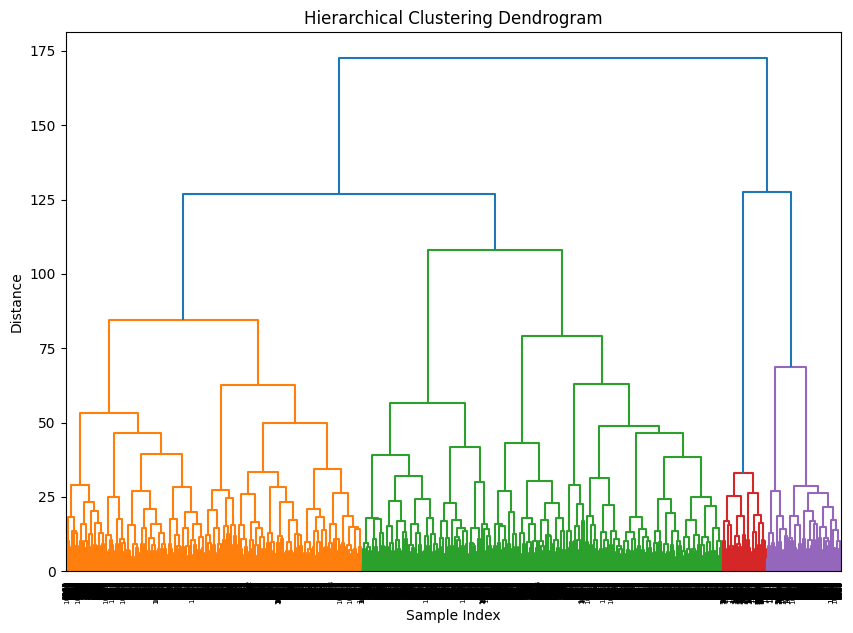

In [3]:
# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()
data['Cluster'] = clusters